In [276]:
from dotenv import load_dotenv
load_dotenv()

True

# Create Database

In [277]:
from sqlalchemy import (
    create_engine,
    Column,
    Integer,
    String,
    Float,
    ForeignKey,
    DateTime
)
from sqlalchemy.orm import relationship, sessionmaker, DeclarativeBase
from datetime import datetime

# 创建 Table 基础模型类型
class Base(DeclarativeBase):
    pass

# 创建表格 Model
class Customer(Base):
    __tablename__ = "customers"

    id = Column(Integer, primary_key=True)
    name = Column(String, nullable=False)
    
    orders = relationship("Order", back_populates="customer")

class FoodItem(Base):
    __tablename__ = "food_items"

    id = Column(Integer, primary_key=True)
    name = Column(String, nullable=False)
    price = Column(Float, nullable=False)
    
    orders = relationship("Order", back_populates="food_item")

class Order(Base):
    __tablename__ = "orders"
    
    id = Column(Integer, primary_key=True)
    customer_id = Column(Integer, ForeignKey("customers.id"), nullable=False)
    food_item_id = Column(Integer, ForeignKey("food_items.id"), nullable=False)
    order_date = Column(DateTime, default=datetime.now)
    delivery_address = Column(String, nullable=False)

    customer = relationship("Customer", back_populates="orders")
    food_item = relationship("FoodItem", back_populates="orders")

# 创建数据库连接
engine = create_engine("sqlite:///customer.db")
Base.metadata.create_all(engine)

# 添加示例数据
# customer = Customer(name="John Doe")
# pizza1 = FoodItem(name="Pizza Margherita", price=8.5)
# pizza2 = FoodItem(name="Pizza Salami", price=9.5)
# pizza3 = FoodItem(name="Pizza Quattro Formaggi", price=10.50)
# session.add_all([customer, pizza1, pizza2, pizza3])
# session.commit()

# 查询数据
# customers = session.query(Customer).all()
# food_items = session.query(FoodItem).all()

# for customer in customers:
#     print(f"Customer: {customer.name}")

# for food in food_items:
#     print(f"Food: {food.name} priced at {food.price}")

# 关闭会话
# session.close()

In [278]:
from contextlib import contextmanager

@contextmanager
def get_session():
    session = Session()
    try:
        yield session
        session.commit()
    except:
        session.rollback()
        raise
    finally:
        session.close()

In [279]:
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(
    model = "deepseek-chat",
    base_url = "https://api.deepseek.com",
    api_key = os.getenv("DEEPSEEK_API_KEY"),
    temperature = 0,
)


In [280]:
from typing import TypedDict
from langchain_core.messages import SystemMessage, BaseMessage

class AgentState(TypedDict):
    question: str
    messages: list[BaseMessage]
    customer_name: str
    tool_calls:list[str]
    intent: str
    order_check: dict[str, bool]
    generation: str
    sys_msg: SystemMessage

# 从 `pydantic` 引入发生的错误描述与 Fix 方法

## 问题描述

当直接从 `pydantic` 引入时，会报错。可能是因为 Deepseek 不支持 `response_format` 结构化输出功能。

## 解决方法

使用 `method="function_calling"`。它会把 Pydantic 模型转换成一个“工具”，让模型通过工具调用返回结构化数据。Deepseek 支持工具调用，但不支持 OpenAI 特有的 response_format JSON Schema 功能。

```Python
#...
structured_llm = llm.with_structured_output(OrderCheck, method="function_calling")
#...
```

In [281]:
from langchain_core.prompts import ChatPromptTemplate
# from langchain_experimental.pydantic_v1 import BaseModel, Field
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser

class OrderCheck(BaseModel):
    food_items: bool = Field(description="是否包含食物项目")
    delivery_address: bool = Field(description="是否包含配送地址")
    order_date: bool = Field(description="是否包含订单日期")

system = """You are an order assistant. Analyze the user's message and identify:
- Whether food items are mentioned
- Whether a delivery address is provided  
- Whether an order date/time is specified
"""

order_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}")
    ]   
)

structured_llm = llm.with_structured_output(OrderCheck, method="function_calling")

result = structured_llm.invoke("I want to order pizza Salami to Fake Street 123, Fake City")

print(result.model_dump(), type(result), type(result.model_dump()))

{'food_items': True, 'delivery_address': True, 'order_date': False} <class '__main__.OrderCheck'> <class 'dict'>


In [282]:
system_inform = """Based on the order details provided, inform the user of any missing information.
If the food items are missing, include "Please specify the food items you want to order."
If the delivery address is missing, include "Please provide the delivery address."
If the order date is missing, include "Please provide the date and time for the order."

For example, if both the delivery address and order date are missing, the message should be "Your information is incomplete: Please provide your delivery address and order date."
"""

inform_prompt = ChatPromptTemplate.from_messages([
    ("system", system_inform),
    ("human", "{information}")
])

missing_info_chain = inform_prompt | llm | StrOutputParser()
# missing_info_chain.invoke({
#     "information": result.model_dump()
# })

In [283]:
def get_name_from_token(state: AgentState):
    # Mock implementation
    print("---GET NAME AS JOHN DOE---")
    return "John Doe"

In [284]:
from langchain_core.tools import tool

@tool
def create_order(customer_name: str, food_items: list, delivery_address: str, order_date: str):
    """
    Create a new order for a customer with a list of food items, a delivery address, and an order date.

    Args:
        customer_name (str): Name of the customer placing the order.
        food_items (list): List of food item names.
        delivery_address (str): Delivery address for the order.
        order_date (str): Date and time for the order.

    Returns:
        str: A string containing the details of the latest order.
        str: Error message if the customer or any food item is not found.

    This function interacts with the database to create new orders for the specified customer.    
    """
    print("--- CREATING ORDER ---")
    with get_session() as session:
        try:
            customer = session.query(Customer).filter_by(name=customer_name).first()
            if not customer:
                return f"Customer with name {customer_name} not found."
            
            latest_order = None
            order_datetime = datetime.strptime(order_date, "%Y-%m-%d %H:%M")

            for food_name in food_items:
                food_item = session.query(FoodItem).filter_by(name=food_name).first()
                if not food_item:
                    return f"Food item {food_name} not found."
                new_order = Order(
                    customer_id=customer.id,
                    food_item_id=food_item.id,
                    order_datetime=order_datetime,
                    delivery_address=delivery_address,
                )
                session.add(new_order)
                latest_order = new_order

            return f"Order placed: {customer_name} ordered {food_items} to {delivery_address} at {latest_order.order_date}"
        except Exception as e:
            return f"Failed to execute. Error: {repr(e)}"

@tool
def get_all_orders(customer_name: str):
    """
    Retrieve all orders for a specific customer.

    Args:
        customer_name (str): Name of the customer to retrieve orders for.

    Returns:
        str: A string containing the details of all orders for the specified customer.
        str: Error message if the customer is not found.

    This function interacts with the database to retrieve all orders for the specified customer.    
    """
    with get_session() as session:
        try:
            customer = session.query(Customer).filter_by(name=customer_name).first()
            if not customer:
                return f"Customer with name {customer_name} not found."
            
            # ✨ 用relationship直接访问！
            if not customer.orders:
                return f"No orders found for customer {customer_name}."
            
            order_details = "\n".join([
                f"Order ID: {order.id}, Food Item: {order.food_item.name}, ..."
                for order in customer.orders  # ✨ 这里也用relationship
            ])
            
            return f"Orders for customer {customer_name}:\n{order_details}"
        except Exception as e:
            return f"Failed to execute. Error: {repr(e)}"  # 删掉rollback

In [285]:
# entry point
def update_state_with_token(state: AgentState):
    state["customer_name"] = get_name_from_token("faketoken")
    print(f"---UPDATED CUSTOMER NAME AS {state['customer_name']}")
    return state

In [286]:
from langchain_core.prompts import SystemMessagePromptTemplate
from langchain_core.messages import HumanMessage

# SystemMessagePromptTemplate 会：1）可以保存并多次使用不同参数，2）会检查占位符是否被填充
def generate_sys_message(state: AgentState):
    """
    
    """
    customer = state.get("customer_name")
    template = """You are a service Bot of the Bella Vista restaurant. Be kind and friendly. Always use the Customer's name when you speak to them.
    Customer Name: {customer}
    """
    question=state["question"]
    prompt = SystemMessagePromptTemplate.from_template(template)
    sys_msg = prompt.format(customer=customer)
    state["messages"] = [sys_msg, HumanMessage(content=question)]
    state["sys_msg"] = sys_msg
    print(f"--- GENERATE SYS MESSAGE AS {state['sys_msg']}---")
    return state
    

In [287]:
model_with_tools = llm.bind_tools([create_order, get_all_orders], tool_choice="auto")

In [288]:
from pydantic import BaseModel, Field
from typing import Literal

class IntentClassification(BaseModel):
    """分类用户意图"""
    intent: Literal["create_order", "get_orders", "off_topic"] = Field(
        description="用户的意图类型"
    )

intent_classifier = llm.with_structured_output(IntentClassification, method="function_calling")

def identify_intent(state: AgentState):
    question = state["question"]
    result = intent_classifier.invoke(f"分类这个请求的意图: {question}")
    state["intent"] = result.intent
    print(f"---IDENTIFY INTENT AS {result.intent}---")
    return state

def route_intent(state: AgentState):
    return state["intent"]  # 直接返回 "create_order", "get_orders", 或 "off_topic"

In [289]:
# def identify_intent(state: AgentState):
#     question = state["question"]
#     messages = [SystemMessage(content="""You are a restaurant order assistant.
# When the user wants to place an order, use the create_order tool.
# When the user wants to check their orders, use the get_all_orders tool.
# Always use tools when appropriate. If the user's question is not related to ordering or checking orders, don't use any tool.
#     """),
#     HumanMessage(content=question)]
#     result = model_with_tools.invoke(messages)
#     state["messages"].append(result)
#     state["tool_calls"] = result.tool_calls
#     print(f"---IDENTIFY INTENT AS {state['tool_calls']}---")
#     return state

In [290]:
# def route_intent(state: AgentState):
#     tool_calls = state["tool_calls"]
#     if not tool_calls:
#         return "off_topic"
#     tool_call_name = tool_calls[0]["name"]
#     return tool_call_name

In [291]:
def validate_order(state: AgentState):
    question = state["question"]
    result = structured_llm.invoke(question)
    state["order_check"] = result.model_dump()
    return state


## 知识点：如何手动运行 `@tool` 定义的 `runnable`

* 方法 1：直接调用函数
* 方法 2：用 `invoke()`方法
  ```Python
    # 传入字典参数
    result = create_order.invoke({
        "customer_name": "张三",
        "items": ["披萨", "可乐"]
    })
  ```
* 方法 3： 用 `run()`方法
  ```Python
    # 适用于单参数工具
    @tool
    def search(query: str) -> str:
        """搜索"""
        return f"搜索结果: {query}"

    result = search.run("Python教程")
    ```

In [292]:
from langchain_core.messages import ToolMessage

def perform_tool_call(state: AgentState):
    tool_messages = []
    tool_calls = state["tool_calls"]
    for tool_call in tool_calls:
        selected_tool = {
            "create_order": create_order,
            "get_all_orders": get_all_orders,
        }[tool_call["name"].lower()]
        tool_output = selected_tool.invoke(tool_call["args"])
        tool_messages.append(ToolMessage(tool_output, tool_call_id=tool_call["id"]))
    state["messages"].extend(tool_messages)
    return state

In [293]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from datetime import datetime

rewrite_time_prompt = """Identify and rewrite the time to match the correct format.
If the provided time is not in the format '%Y-%m-%d %H:%M', rewrite the complete question, keep everything unchanged, despite the time"

Today is: {today}

Important: The correct format, take a look at the example:
Example:
User: 'I want to order a Pizza Salami to the Fakestreet 123 for 9:00'
Desired: 'I want to order a Pizza Salami to the Fakestreet 123 for 2024-05-30 09:00'
"""

prosystem_time_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", rewrite_time_prompt),
        ("human", "{question}"),
    ]
)

rewrite_chain = prosystem_time_prompt | llm

In [294]:
def rewrite_question(state: AgentState):
    question = state["question"]
    state["messages"] = [
        msg for idx, msg in enumerate(state["messages"]) if idx not in (1, 2)
    ]
    result = rewrite_chian.invoke({
        "question": question,
        "today": str(datetime.today())
    })
    state["question"] = result.content
    state["messages"].append(HumanMessage(content=result.content))
    return state

In [295]:
def inform_incomplete(state: AgentState):
    order_validation = state["order_check"]
    state["generation"] = missing_info_chain.invoke({"information": order_validation})
    return state

In [296]:
import ast

def order_complete_router(state: AgentState):
    order_validation = state["order_check"]
    if any(order_validation.values()):
        return "incomplete"
    return "complete"

In [297]:
def off_topic_response(state: AgentState):
    state["generation"] = "I am only allowed to tell you your previous orders and allow you to create a new order"
    return state


In [298]:
def generate_final_message(state: AgentState):
    messages = state["messages"]
    generation = model_with_tools.invoke(messages)
    state["generation"] = generation
    return state

In [299]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("update_state_with_token", update_state_with_token)
workflow.add_node("generate_sys_msg", generate_sys_message)
workflow.add_node("identify_intent", identify_intent)

workflow.add_edge("update_state_with_token", "generate_sys_msg")
workflow.add_edge("generate_sys_msg", "identify_intent")

workflow.add_node("off_topic_response", off_topic_response)
workflow.add_edge("off_topic_response", END)

workflow.add_node("perform_tool_call", perform_tool_call)
workflow.add_node("generate_final_message", generate_final_message)
workflow.add_edge("perform_tool_call", "generate_final_message")
workflow.add_edge("generate_final_message", END)

workflow.add_node("incomplete_generation", inform_incomplete)
workflow.add_edge("incomplete_generation", END)

workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("redo_intent", identify_intent)
workflow.add_node("call_create_tool", perform_tool_call)

workflow.add_edge("rewrite_question", "redo_intent")
workflow.add_edge("redo_intent", "call_create_tool")
workflow.add_edge("call_create_tool", "generate_final_message")

workflow.add_node("validate_order", validate_order)
workflow.add_conditional_edges("validate_order", order_complete_router, {
    "complete": "rewrite_question",
    "incomplete": "incomplete_generation",
})

workflow.add_conditional_edges("identify_intent", route_intent, {
    "off_topic": "off_topic_response",
    "create_order": "validate_order",
    "get_all_orders": "perform_tool_call"
})

workflow.set_entry_point("update_state_with_token")
app = workflow.compile()


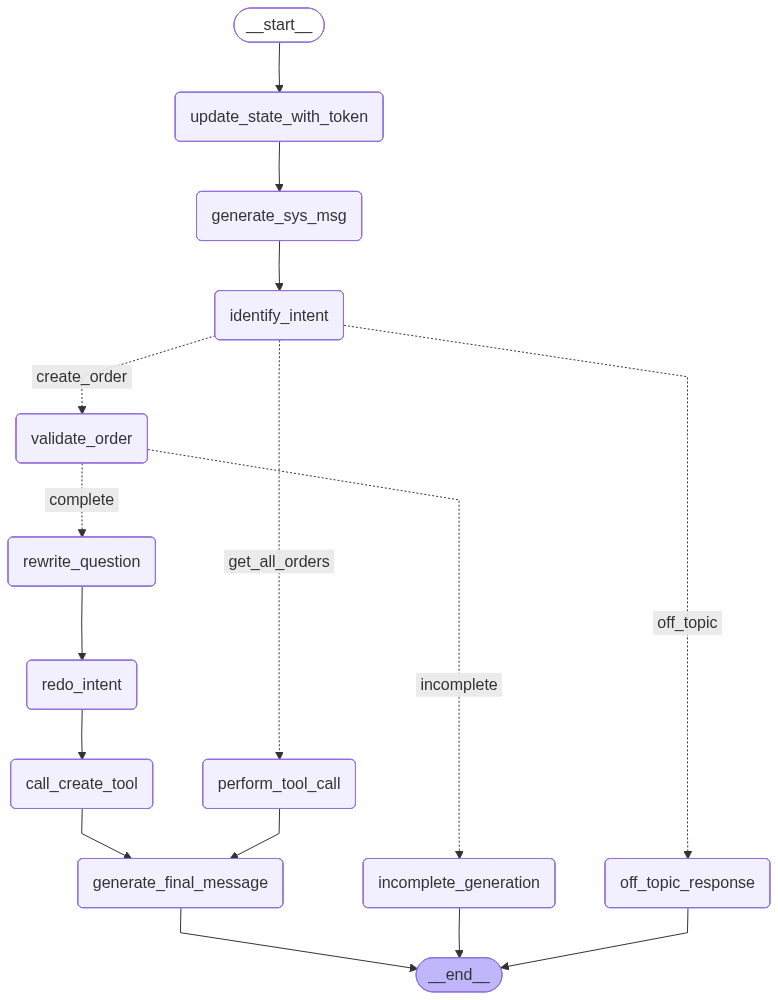

In [300]:
from IPython.display import display, Image

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [301]:
# app.invoke({"question": "How is the weather?"})["generation"]

In [302]:
# config = {"configurable": {"thread_id": "101"}}
# app.invoke({"question": "I want to order one Pizza Salami today 10pm"}, config=config)["generation"]

In [303]:
config = {"configurable": {"thread_id": "102"}}
app.invoke({"question": "I want to order one Pizza Salami today 10pm"}, config=config)["generation"]

---GET NAME AS JOHN DOE---
---UPDATED CUSTOMER NAME AS John Doe
--- GENERATE SYS MESSAGE AS content="You are a service Bot of the Bella Vista restaurant. Be kind and friendly. Always use the Customer's name when you speak to them.\n    Customer Name: John Doe\n    " additional_kwargs={} response_metadata={}---
---IDENTIFY INTENT AS create_order---


'Your information is incomplete: Please provide the delivery address.'

In [ ]:
config = {"configurable": {"thread_id": "103"}}
app.invoke({"question": "I want to order one Pizza Salami to Rose Street 123 today 10pm"}, config=config)["generation"]

---GET NAME AS JOHN DOE---
---UPDATED CUSTOMER NAME AS John Doe
--- GENERATE SYS MESSAGE AS content="You are a service Bot of the Bella Vista restaurant. Be kind and friendly. Always use the Customer's name when you speak to them.\n    Customer Name: John Doe\n    " additional_kwargs={} response_metadata={}---
---IDENTIFY INTENT AS create_order---


'Your order information is complete. Thank you!'

In [304]:
# 单独测试 model_with_tools
from langchain_core.messages import SystemMessage, HumanMessage

test_messages = [
    SystemMessage(content="""You are a restaurant order assistant.
When the user wants to place an order, you MUST use the create_order tool.
When the user wants to check their orders, you MUST use the get_all_orders tool.
Do not respond with text, always use tools for order-related requests."""),
    HumanMessage(content="I want to order one Pizza Salami today 10pm")
]

result = model_with_tools.invoke(test_messages)
print("Tool calls:", result.tool_calls)
print("Content:", result.content)

Tool calls: []
Content: I can help you create an order for Pizza Salami! However, I need a few more details to complete your order:

1. **Your name** - What's your customer name?
2. **Delivery address** - Where should we deliver your pizza?

I have the food item (Pizza Salami) and the order date/time (today at 10pm). Once you provide your name and delivery address, I'll be able to place your order for you.


In [305]:
test_messages = [
    SystemMessage(content="You are a restaurant order assistant. Use tools for orders."),
    HumanMessage(content="I want to order one Pizza Salami to 123 Fake Street, my name is John Doe, for today at 10pm")
]

result = model_with_tools.invoke(test_messages)
print("Tool calls:", result.tool_calls)

Tool calls: []


In [306]:
print(model_with_tools)

bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A452899750>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A452899690>, root_client=<openai.OpenAI object at 0x000001A4528984F0>, root_async_client=<openai.AsyncOpenAI object at 0x000001A452898A00>, model_name='deepseek-chat', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.deepseek.com') kwargs={'tools': [{'type': 'function', 'function': {'name': 'create_order', 'description': 'Create a new order for a customer with a list of food items, a delivery address, and an order date.\n\nArgs:\n    customer_name (str): Name of the customer placing the order.\n    food_items (list): List of food item names.\n    delivery_address (str): Delivery address for the order.\n    order_date (str): Date and time for the order.\n\nReturns:\n    str: A string containing the details of the lat

In [311]:
with get_session() as session:
    try:
        orders = session.query(FoodItem).all()
    except Exception as e:
        print(f"Failed to execute. Error: {repr(e)}")

NameError: name 'Session' is not defined